# Modelo de predição de valor da bolsa do BTG Pactual
---
Instruções:
"Seu desafio é criar um modelo preditivo de redes neurais Long Short Term Memory (LSTM) para predizer o valor de fechamento da bolsa de valores de uma empresa à sua escolha e realizar toda a pipeline de desenvolvimento, desde a criação do modelo preditivo até o deploy do modelo em uma API que permita a previsão de preços de ações."

## Importação das bibliotecas necessárias

In [24]:

import yfinance as yf

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from math import sqrt

import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

import mlflow
import mlflow.keras

In [25]:
import os

## Carregamento e limpeza dos dados

In [26]:
# Símbolo do BTG Pactual listado na B3 (unidades): BPAC11.SA
symbol = 'BPAC11.SA'
start_date = '2015-01-01'
end_date = '2025-07-01'

df = yf.download(symbol, start=start_date, end=end_date)

C:\Users\maria\AppData\Local\Temp\ipykernel_10520\1229583237.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [27]:
# Verificando o DF

df.head()

Price,Close,High,Low,Open,Volume
Ticker,BPAC11.SA,BPAC11.SA,BPAC11.SA,BPAC11.SA,BPAC11.SA
Date,,,,,
2017-02-24,3.469847,3.469847,3.469847,3.469847,5200
2017-03-01,3.422184,3.469847,3.422184,3.469847,17200
2017-03-02,3.422184,3.422184,3.422184,3.422184,0
2017-03-03,3.574704,3.622367,3.527042,3.622367,7200
2017-03-06,3.660497,3.717693,3.527042,3.584237,22800


In [28]:
# Shape do DF

df.shape

(2076, 5)

In [29]:
# Verificando nomes das colunas 

df.columns

MultiIndex([( 'Close', 'BPAC11.SA'),
            (  'High', 'BPAC11.SA'),
            (   'Low', 'BPAC11.SA'),
            (  'Open', 'BPAC11.SA'),
            ('Volume', 'BPAC11.SA')],
           names=['Price', 'Ticker'])

In [30]:
# Formatando o nome das colunas do df

i = 0
columns = []

for column in df.columns:
    column_name = df.columns[i][0]
    i += 1
    columns.append(column_name)
    # print(column_name)

print(columns)

['Close', 'High', 'Low', 'Open', 'Volume']


In [31]:
# Renomeando colunas para as que estão contidas em columns 

df.columns = columns

df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2017-02-24,3.469847,3.469847,3.469847,3.469847,5200
2017-03-01,3.422184,3.469847,3.422184,3.469847,17200
2017-03-02,3.422184,3.422184,3.422184,3.422184,0
2017-03-03,3.574704,3.622367,3.527042,3.622367,7200
2017-03-06,3.660497,3.717693,3.527042,3.584237,22800


In [32]:
# Transformando o Index (data) em uma coluna de data

df.reset_index(inplace=True)

df.head()

,Date,Close,High,Low,Open,Volume
0,2017-02-24,3.469847,3.469847,3.469847,3.469847,5200
1,2017-03-01,3.422184,3.469847,3.422184,3.469847,17200
2,2017-03-02,3.422184,3.422184,3.422184,3.422184,0
3,2017-03-03,3.574704,3.622367,3.527042,3.622367,7200
4,2017-03-06,3.660497,3.717693,3.527042,3.584237,22800


In [33]:
# Selecionando apenas as colunas que importam 

df = df[['Date', 'Close']]

df.head()

,Date,Close
0,2017-02-24,3.469847
1,2017-03-01,3.422184
2,2017-03-02,3.422184
3,2017-03-03,3.574704
4,2017-03-06,3.660497


In [34]:
# Verificando o tipo de dados das colunas:

print(df.dtypes)

Date     datetime64[ns]
Close           float64
dtype: object


In [35]:
# Procurando por valores nulos

df.isnull().sum()

Date     0
Close    0
dtype: int64

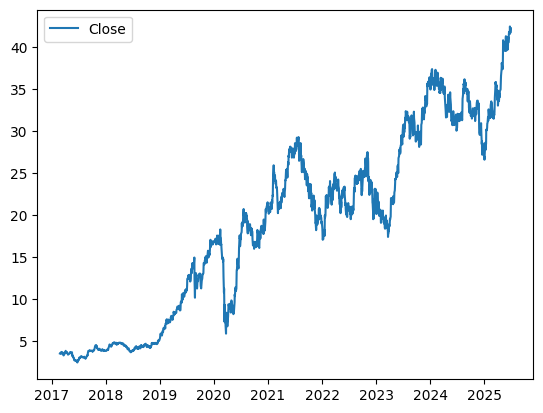

In [36]:
# Plotando para verificar o comportamento e sua relação com a data 

plt.plot(df['Date'], df['Close'], label='Close')
plt.legend()
plt.show()

## Pré processamento dos dados

In [37]:
scaler = MinMaxScaler(feature_range=(0, 1))

In [38]:
df_processado = scaler.fit_transform(df['Close'].values.reshape(-1, 1))

In [39]:
# Queremos prever ações nos últimos 60 dias, então...
previsao_em_dias = 60

In [40]:
# Função que cria as sequências 

def cria_sequencias(dado, previsao_em_dias):
  x, y = [], []

  for i in range(previsao_em_dias, len(df_processado)):
      x.append(df_processado[i-previsao_em_dias:i, 0])
      y.append(df_processado[i, 0])

  return np.array(x), np.array(y)

x, y = cria_sequencias(df_processado, previsao_em_dias)
x = x.reshape((x.shape[0], x.shape[1], 1))

In [41]:
print(x.shape)

(2016, 60, 1)


## Separando dados em treino e teste

In [42]:
train_size = int(len(x) * 0.8)
x_train, x_test = x[:train_size], x[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

## Modelo

In [43]:
# Criar pasta para salvar modelo local (se não existir)
model_path = os.path.join("models_saved", "modelo_lstm.h5")
os.makedirs("models_saved", exist_ok=True)

In [44]:
# Configurar experimento MLflow
mlflow.set_experiment("Previsao_Stock_LSTM")
mlflow.keras.autolog()

# Criar pasta para salvar modelo local, se não existir
os.makedirs("../models_saved", exist_ok=True)

with mlflow.start_run():
    # Configurar callback para early stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=10)
    
    # Definir modelo
    modelo = Sequential()
    modelo.add(LSTM(50, input_shape=(previsao_em_dias, 1)))
    modelo.add(Dense(1))
    modelo.compile(loss='mean_squared_error', optimizer='adam')
    
    # Treinar modelo
    modelo.fit(
        x_train, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1
    )
    
    # Fazer predição no conjunto de teste
    y_pred_scaled = modelo.predict(x_test)
    
    # Desscalar predições e valores reais
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_real = scaler.inverse_transform(y_test.reshape(-1, 1))
    
    # Calcular RMSE real
    rmse = sqrt(mean_squared_error(y_real, y_pred))
    print(f'RMSE: {rmse:.4f}')
    
    # Logar RMSE explicitamente (opcional, autolog já registra)
    mlflow.log_metric("rmse", rmse)
    
    # Salvar modelo localmente
    try:
        modelo.save("../models_saved/modelo_lstm.h5")
        print("Modelo salvo com sucesso!")
    except Exception as e:
        print(f"Erro ao salvar modelo: {e}")
    
    print(f"Preço médio real: {y_real.mean():.2f}")
    erro_percentual = (rmse / y_real.mean()) * 100
    print(f"Erro percentual médio aproximado: {erro_percentual:.2f}%")


c:\Users\maria\OneDrive\Documentos\FIAP\entrega_4\.env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - loss: 0.0373 - val_loss: 0.0011
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 9.5986e-04 - val_loss: 8.8829e-04
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 5.6213e-04 - val_loss: 0.0011
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 5.4214e-04 - val_loss: 7.9438e-04
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 4.9270e-04 - val_loss: 8.0548e-04
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 4.9372e-04 - val_loss: 8.1315e-04
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 5.0463e-04 - val_loss: 8.1637e-04
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 4.0824e-04 - val_loss: 6.8069e-04
Epoch 9/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 4.8522e-04 - val_loss: 7.7903e-04
Epoch 10/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 3.9097e-04 - val_loss: 6.3373e-04
Epoch 11/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 3.6185e-04 - val_los

2025/07/05 15:09:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step
RMSE: 0.9106


Modelo salvo com sucesso!
Preço médio real: 33.88
Erro percentual médio aproximado: 2.69%


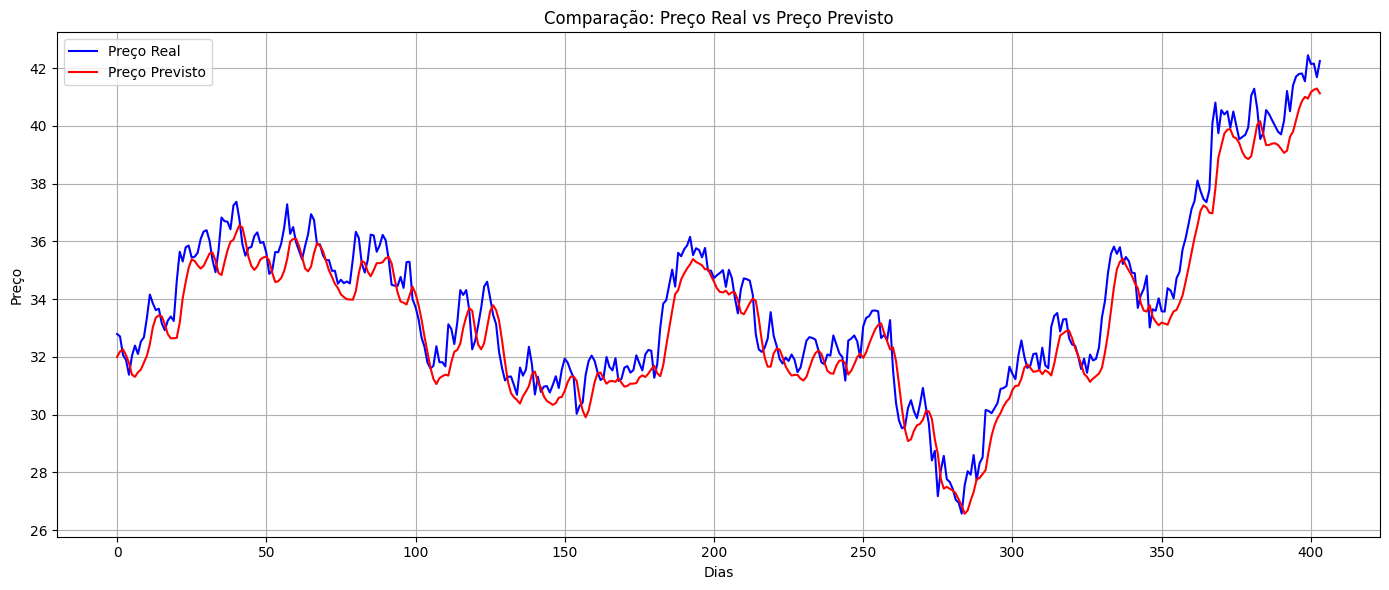

In [45]:
# Comparando o predito e o valor real de Y

plt.figure(figsize=(14,6))
plt.plot(y_real, label="Preço Real", color='blue')
plt.plot(y_pred, label="Preço Previsto", color='red')
plt.title("Comparação: Preço Real vs Preço Previsto")
plt.xlabel("Dias")
plt.ylabel("Preço")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [46]:
# 4. Salvar localmente como .h5
modelo.save("modelo_lstm.h5")